Customer Sales Data 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the datasets

df = pd.read_csv('customer_sales_data.csv')
print(df)

    Customer_ID  Gender  Age Region Product_Category  Units_Purchased  \
0          C001    Male   52  South         Clothing                9   
1          C002  Female   52   West          Grocery                7   
2          C003    Male   50  North         Clothing                4   
3          C004    Male   22   West         Clothing               10   
4          C005    Male   59   West         Clothing                5   
..          ...     ...  ...    ...              ...              ...   
145        C146    Male   47  South         Clothing               10   
146        C147    Male   59   West         Clothing                8   
147        C148    Male   52  South         Clothing               10   
148        C149    Male   24   West         Clothing                2   
149        C150  Female   33   East          Grocery                5   

     Price_Per_Unit Purchase_Date  Total_Amount  
0               340    2026-03-14          3060  
1               789    

In [3]:
# First 5 rows 

print(df.head())



  Customer_ID  Gender  Age Region Product_Category  Units_Purchased  \
0        C001    Male   52  South         Clothing                9   
1        C002  Female   52   West          Grocery                7   
2        C003    Male   50  North         Clothing                4   
3        C004    Male   22   West         Clothing               10   
4        C005    Male   59   West         Clothing                5   

   Price_Per_Unit Purchase_Date  Total_Amount  
0             340    2026-03-14          3060  
1             789    2026-09-06          5523  
2            2246    2026-02-16          8984  
3            1524    2026-05-01         15240  
4            1228    2026-08-02          6140  


In [4]:
# Disply Colums name and data type and shpe 

print(df.columns)

print(df.dtypes)

print(df.shape)

Index(['Customer_ID', 'Gender', 'Age', 'Region', 'Product_Category',
       'Units_Purchased', 'Price_Per_Unit', 'Purchase_Date', 'Total_Amount'],
      dtype='str')
Customer_ID           str
Gender                str
Age                 int64
Region                str
Product_Category      str
Units_Purchased     int64
Price_Per_Unit      int64
Purchase_Date         str
Total_Amount        int64
dtype: object
(150, 9)


In [5]:
#  Convert Purchase_Date to datetime.

df['Purchase_Date'] = pd.to_datetime(df['Purchase_Date'])

print(df.dtypes)

Customer_ID                    str
Gender                         str
Age                          int64
Region                         str
Product_Category               str
Units_Purchased              int64
Price_Per_Unit               int64
Purchase_Date       datetime64[us]
Total_Amount                 int64
dtype: object


In [6]:
# numpy 

# Average

average_total = np.mean(df['Total_Amount']) 

average_units = np.mean(df['Units_Purchased'])

# Highest Purchased 

maximum_order = np.max(df['Total_Amount'])

# Lowest Purchased

minimum_order = np.min(df['Total_Amount'])

print("NumPy Calculation: ")
print("Average total amount: ",average_total)
print("Average units purchased:", average_units)

print("Highest Purchased Amount: ",maximum_order)
print("Lowest Purchased Amount: ",minimum_order)

NumPy Calculation: 
Average total amount:  8431.473333333333
Average units purchased: 5.793333333333333
Highest Purchased Amount:  44622
Lowest Purchased Amount:  309


In [7]:
# Data Analysis 

# Group By

gender = df.groupby("Gender")["Units_Purchased"].sum()

print(gender)

region = df.groupby("Region")["Units_Purchased"].sum()
print(region)

product_category = df.groupby('Product_Category')["Units_Purchased"].sum()
print(product_category)

monthly_order = df.groupby(df['Purchase_Date'].dt.to_period('M')).size()
print(monthly_order)

weekly_order = df.groupby(df['Purchase_Date'].dt.to_period('W')).size()
print(weekly_order)


Gender
Female    459
Male      410
Name: Units_Purchased, dtype: int64
Region
East     165
North    218
South    200
West     286
Name: Units_Purchased, dtype: int64
Product_Category
Beauty         179
Clothing       261
Electronics    134
Grocery        124
Sports         171
Name: Units_Purchased, dtype: int64
Purchase_Date
2026-01    26
2026-02    14
2026-03    20
2026-04    19
2026-05    17
2026-06    11
2026-07     9
2026-08    22
2026-09    12
Freq: M, dtype: int64
Purchase_Date
2025-12-29/2026-01-04    5
2026-01-05/2026-01-11    6
2026-01-12/2026-01-18    6
2026-01-19/2026-01-25    4
2026-01-26/2026-02-01    5
2026-02-02/2026-02-08    6
2026-02-09/2026-02-15    3
2026-02-16/2026-02-22    3
2026-02-23/2026-03-01    3
2026-03-02/2026-03-08    5
2026-03-09/2026-03-15    4
2026-03-16/2026-03-22    4
2026-03-23/2026-03-29    3
2026-03-30/2026-04-05    7
2026-04-06/2026-04-12    2
2026-04-13/2026-04-19    3
2026-04-20/2026-04-26    7
2026-04-27/2026-05-03    4
2026-05-04/2026-05-10   

#
🔹 Visualization

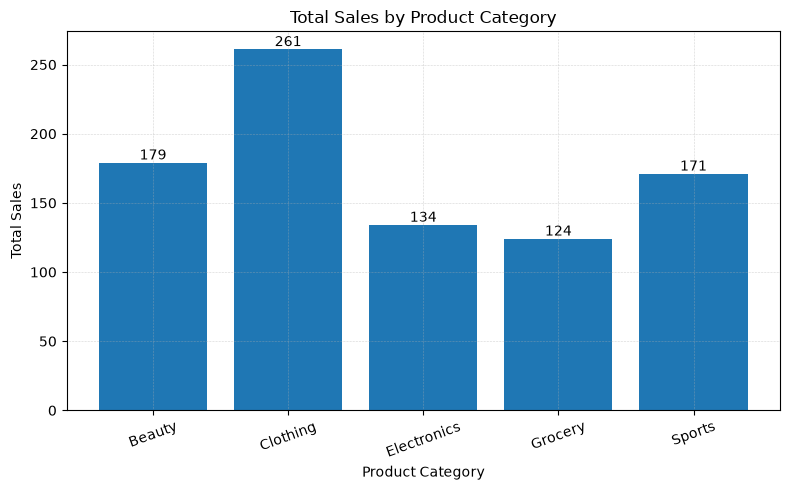

In [8]:
# Bar chart

# Plot a bar chart of total sales by Product Category.

plt.figure(figsize=(8, 5))

plt.bar(
    product_category.index,
    product_category.values
)

plt.title("Total Sales by Product Category")


plt.xlabel('Product Category')
plt.ylabel('Total Sales')

# Add values on top of bars
for i, value in enumerate(product_category.values):
    plt.text(i, value, str(value), ha='center', va='bottom')

plt.xticks(rotation=20)

plt.grid(linestyle=':', linewidth = 0.4)

plt.tight_layout()

plt.show()



Region
West     50
North    39
South    32
East     29
Name: count, dtype: int64


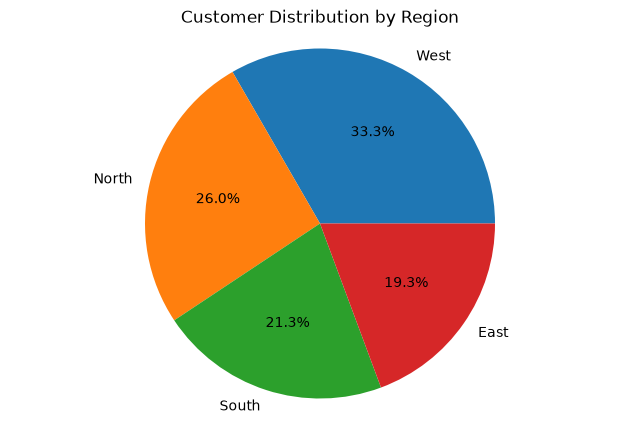

In [9]:
# pie chart

customer_region = df['Region'].value_counts()
print(customer_region)

plt.figure(figsize=(8, 5))

plt.pie(
    customer_region.values,
    labels=customer_region.index,
    autopct='%1.1f%%',
)

plt.title("Customer Distribution by Region")
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()


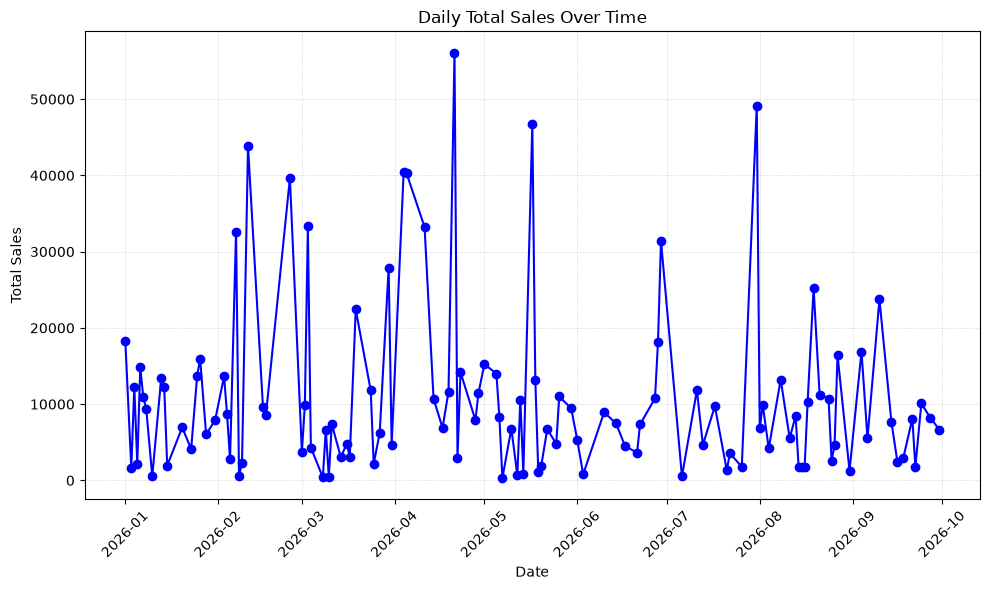

In [10]:
# line chart

#  Plot a line chart of daily total sales over time.

daily_sales = df.groupby(df['Purchase_Date'].dt.date)['Total_Amount'].sum()

plt.figure(figsize=(10, 6))

plt.plot(
    daily_sales.index,
    daily_sales.values,
    marker='o',
    linestyle='-',
    color='b'
)

plt.title("Daily Total Sales Over Time")
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.grid(linestyle=':', linewidth=0.4)
plt.tight_layout()

plt.show()

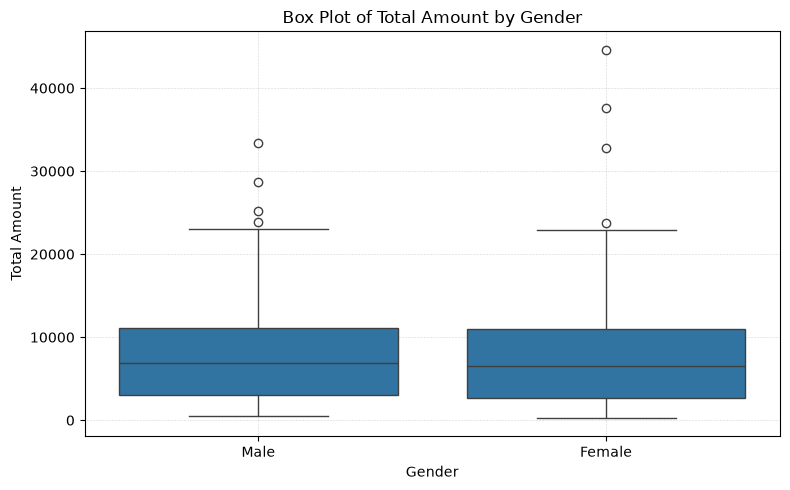

In [11]:
'''
 10. Use Seaborn:
•   Create a box plot of Total_Amount by Gender.
'''

# sea born box plot

plt.figure(figsize=(8, 5))
sns.boxplot(x='Gender', y='Total_Amount', data=df)

plt.title("Box Plot of Total Amount by Gender")
plt.xlabel('Gender')
plt.ylabel('Total Amount')
plt.grid(linestyle=':', linewidth=0.4)
plt.tight_layout()

plt.show()

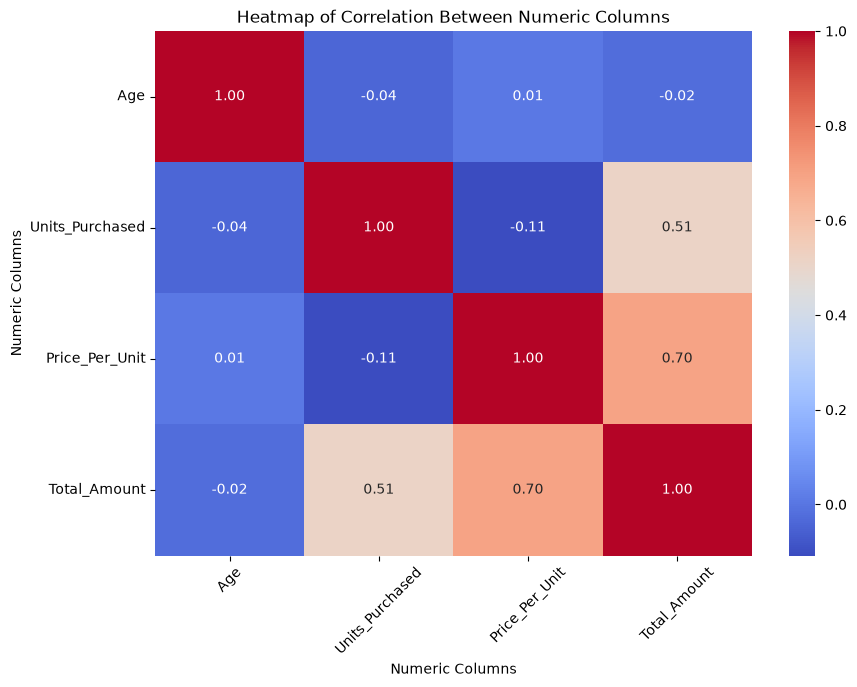

In [13]:
# Create a heatmap of correlation between numeric columns.

numeric_columns = df.select_dtypes(include=[np.number])

correlation_matrix = numeric_columns.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    numeric_columns.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
)

plt.title("Heatmap of Correlation Between Numeric Columns")
plt.tight_layout()
plt.xlabel('Numeric Columns')
plt.ylabel('Numeric Columns')
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.show()